<a href="https://colab.research.google.com/github/matthewacash/north_tx_housing_market_analysis/blob/main/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 02_exploratory_analysis

### Python - Reusable Visualization Functions

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    plt.show()

### Mount Google Drive

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Libraries

In [ ]:
import os

# reading and manipulating data
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns


### Create Base Path

In [ ]:
base_path = '/content/drive/MyDrive/Colab Notebooks/NorthTexasCreditRisk'
os.chdir(base_path)

In [ ]:
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/NorthTexasCreditRisk'

### Load Cleaned Datasets

In [ ]:
#creating dictionary of datasets
datasets = {
    "collin_unemp": "data/cleaned/collin_unemployment_cleaned.csv",
    "dallas_unemp": "data/cleaned/dallas_unemployment_cleaned.csv",
    "denton_unemp": "data/cleaned/denton_unemployment_cleaned.csv",
    "cpi": "data/cleaned/cpi_inflation_cleaned.csv",
    "mortgage": "data/cleaned/mortgage_rates_cleaned.csv",
    "fed_funds": "data/cleaned/fed_funds_rate_cleaned.csv",
    "collin_hpi": "data/cleaned/collin_hpi_cleaned.csv",
    "dallas_hpi": "data/cleaned/dallas_hpi_cleaned.csv",
    "denton_hpi": "data/cleaned/denton_hpi_cleaned.csv"
  }

In [ ]:
#load datasets automatically
dfs = {}

for name, path in datasets.items():
  dfs[name] = pd.read_csv(path)

In [ ]:
#convert dates automatically to datetime object
for name, df in dfs.items():
  if "observation_date" in df.columns:
    df["observation_date"] = pd.to_datetime(
        df["observation_date"]
    )

### Loading Demographic Dataset

In [ ]:
!pip install openpyxl

In [ ]:
df_demographics = pd.read_excel('data/raw/county_demographics.xlsx')

In [ ]:
df_demographics.to_csv('data/cleaned/county_demographics_cleaned.csv', index=False)

In [ ]:
os.listdir('data/cleaned')

['cpi_inflation_cleaned.csv',
 'collin_unemployment_cleaned.csv',
 'dallas_unemployment_cleaned.csv',
 'denton_unemployment_cleaned.csv',
 'mortgage_rates_cleaned.csv',
 'fed_funds_rate_cleaned.csv',
 'collin_hpi_cleaned.csv',
 'dallas_hpi_cleaned.csv',
 'denton_hpi_cleaned.csv',
 'county_demographics_cleaned.xlsx',
 'county_demographics_cleaned.csv']

In [ ]:
os.path.getsize('data/cleaned/county_demographics_cleaned.xlsx')

214

### Unemployment Analysis

* How does unemployment percentages compare across Collin, Dallas, and Denton counties?

In [ ]:
df_collin = dfs["collin_unemp"]
df_dallas = dfs["dallas_unemp"]
df_denton = dfs['denton_unemp']

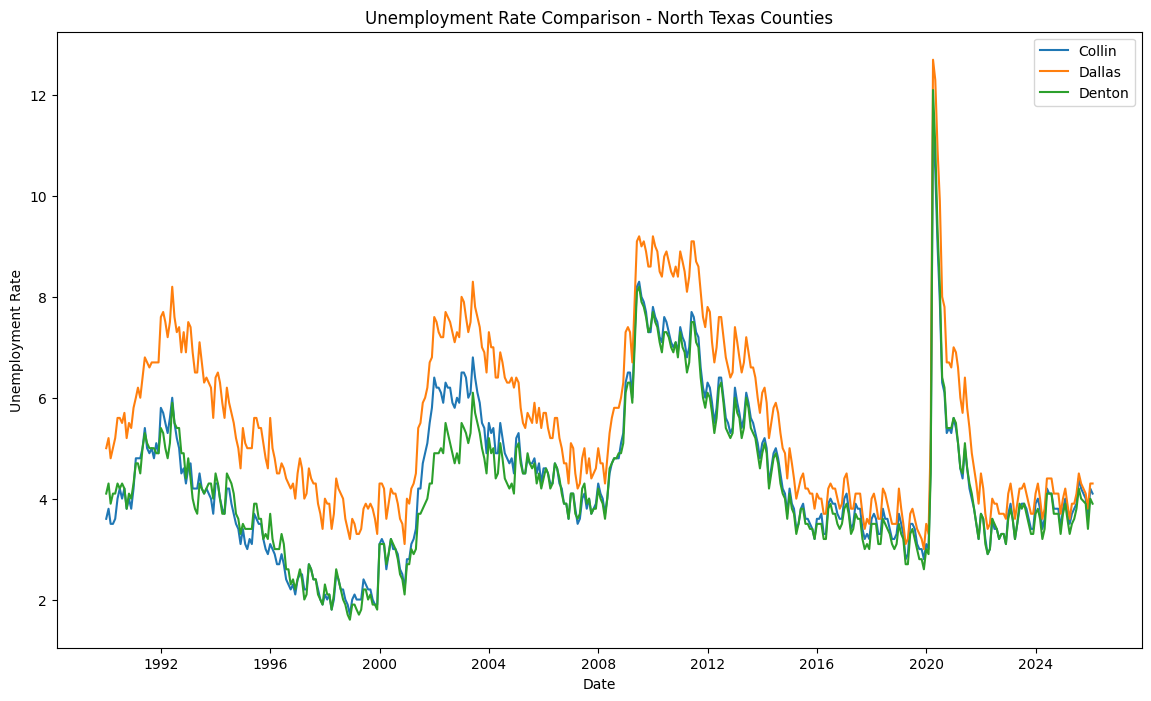

In [ ]:
plt.figure(figsize=(14,8))

plt.plot(df_collin["observation_date"], df_collin.iloc[:,1], label="Collin")
plt.plot(df_dallas["observation_date"], df_dallas.iloc[:,1], label="Dallas")
plt.plot(df_denton["observation_date"], df_denton.iloc[:,1], label="Denton")

plt.title("Unemployment Rate Comparison - North Texas Counties")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()

plt.show()

* Dallas County appears to have consistently higher unemployment rates than Collin and Denton counties.

#### Which County has the most volatile unemployment?

In [ ]:
print(f"Collin County has, {round(df_collin['TXCOLL5URN'].std(),2)}")
print(f"Dallas County has, {round(df_dallas['TXDALL3URN'].std(),2)}")
print(f"Denton County has, {round(df_denton['TXDENT2URN'].std(),2)}")

Collin County has, 1.49
Dallas County has, 1.68
Denton County has, 1.43


* Dallas County has the most volatility at 1.68 standard deviation while Denton has the lowest volatility at 1.43 standard deviation.

#### Do Counties move together and is there an economic link?

In [ ]:
round(df_collin["TXCOLL5URN"].corr(df_dallas["TXDALL3URN"]),4)

np.float64(0.9318)

In [ ]:
round(df_collin['TXCOLL5URN'].corr(df_denton['TXDENT2URN']), 4)

np.float64(0.9795)

In [ ]:
round(df_denton['TXDENT2URN'].corr(df_dallas['TXDALL3URN']), 4)

np.float64(0.9261)

* Each county comparison shows high correlation and suggests that economically, all counties move together as a unit to some extent.

#### Check average unemployment across counties.

In [ ]:
df_collin['TXCOLL5URN'].mean()

np.float64(4.357043879907621)

In [ ]:
df_dallas['TXDALL3URN'].mean()

np.float64(5.496535796766744)

In [ ]:
df_denton['TXDENT2URN'].mean()

np.float64(4.238568129330254)

* Denton has the lowest average unemployment rate across all selected counties at 4.24%.
* Dallas county has the highest average unemployment rate at 5.50%.
* Collin county is slightly higher than Denton county with average unemployment rate at 4.36%.

### Mortgage Rate Analysis

#### How did changes in the 30-year mortgage rates relate to housing price growth in Collin, Dallas, and Denton counties?

In [ ]:
df_mortgage = dfs['mortgage']

In [ ]:
df_mortgage.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [ ]:
df_mortgage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2877 entries, 0 to 2876
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2877 non-null   datetime64[ns]
 1   MORTGAGE30US      2877 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 45.1 KB


In [ ]:
df_mortgage.columns

Index(['observation_date', 'MORTGAGE30US'], dtype='object')

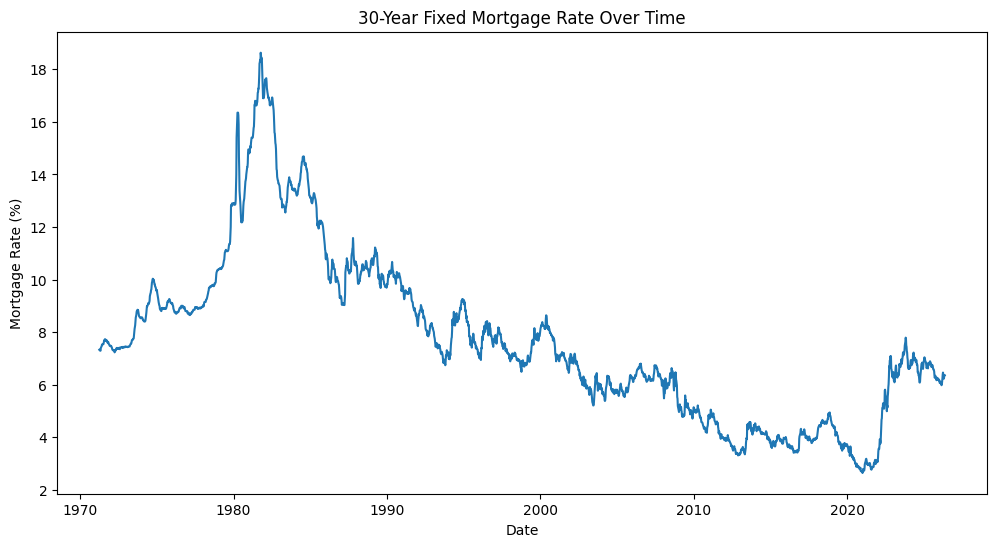

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_mortgage["observation_date"],
    df_mortgage["MORTGAGE30US"]
)

plt.title("30-Year Fixed Mortgage Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Mortgage Rate (%)")

plt.show()

* Lowest rates appear to be around 2021-2022 and below 4% while the highest rates were some where near 1982-1983 and above 18%!

In [ ]:
print("Average rate:", round(df_mortgage["MORTGAGE30US"].mean(),2))
print("Minimum rate:", df_mortgage["MORTGAGE30US"].min())
print("Maximum rate:", df_mortgage["MORTGAGE30US"].max())
print("Standard deviation:", round(df_mortgage["MORTGAGE30US"].std(),2))

Average rate: 7.69
Minimum rate: 2.65
Maximum rate: 18.63
Standard deviation: 3.19


The max mortgage rate was 18.69 % and the lowest rate was 2.65 %.

The rates are this way because the data goes back from the 1970s to present day.

In [ ]:
# finding min and max observation dates for the mortgage data
print(df_mortgage["observation_date"].min())
print(df_mortgage["observation_date"].max())

1971-04-02 00:00:00
2026-05-14 00:00:00


* Mortgage data dates back to April 2, 2971 and ranges up to May 14, 2026.

In [ ]:
# finding min and max dates for unemployment data
print(df_dallas['observation_date'].min())
print(df_dallas['observation_date'].max())


1990-01-01 00:00:00
2026-02-01 00:00:00


* Unemployment data ranges from January 1, 1990 to February 1, 2026

In [ ]:
df_collin_hpi = dfs['collin_hpi']
df_dallas_hpi = dfs['dallas_hpi']
df_denton_hpi = dfs['denton_hpi']

In [ ]:
# finding min and max dates for hpi data
print(df_collin_hpi['observation_date'].min())
print(df_collin_hpi['observation_date'].max())

1975-01-01 00:00:00
2025-01-01 00:00:00


### Date Ranges for Datasets

* Since the date ranges are different for unemployment, mortgage, and HPI, the observations will be restricted to January 1990 through January 2025 to ensure consistent temporal coverage.

### HPI Analysis and Comparison

In [ ]:
#check column comparisons between datasets
df_mortgage.columns, df_collin_hpi.columns

(Index(['observation_date', 'MORTGAGE30US'], dtype='object'),
 Index(['observation_date', 'ATNHPIUS48085A'], dtype='object'))

In [ ]:
#checking data between the two datasets
df_mortgage.head(10)

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29
5,1971-05-07,7.38
6,1971-05-14,7.42
7,1971-05-21,7.44
8,1971-05-28,7.46
9,1971-06-04,7.52


In [ ]:
df_collin_hpi.head(20)

,observation_date,ATNHPIUS48085A
0,1975-01-01,36.17
1,1976-01-01,40.61
2,1977-01-01,43.83
3,1978-01-01,49.36
4,1979-01-01,59.18
5,1980-01-01,66.41
6,1981-01-01,70.43
7,1982-01-01,72.92
8,1983-01-01,79.63
9,1984-01-01,84.13


In [ ]:
df_collin_hpi.shape

(51, 2)

### Mortgage Rate Analysis - Extension

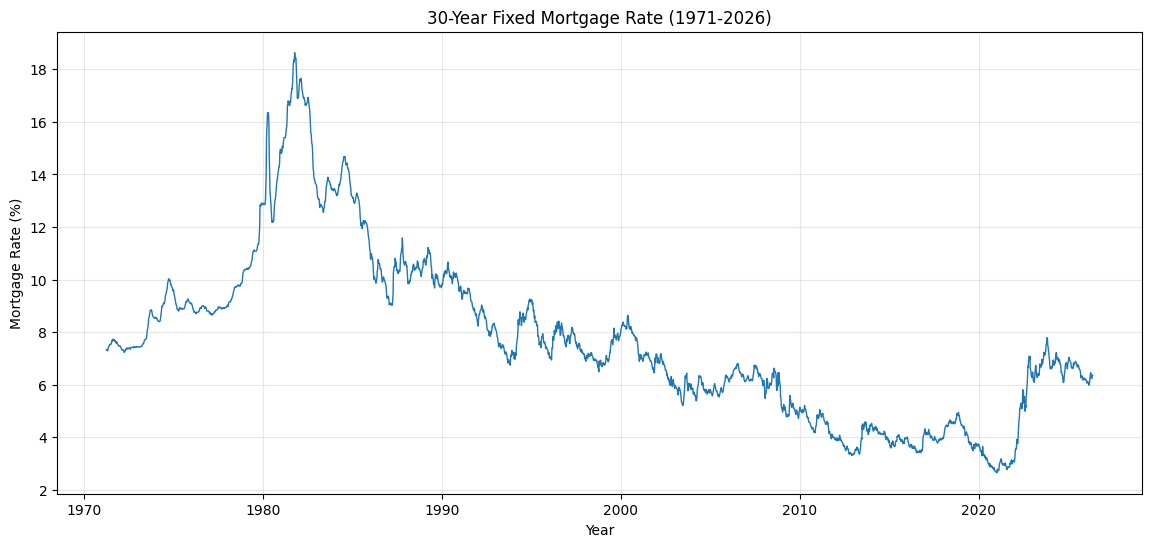

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df_mortgage["observation_date"],
    df_mortgage["MORTGAGE30US"],
    linewidth=1
)

plt.title("30-Year Fixed Mortgage Rate (1971-2026)")
plt.xlabel("Year")
plt.ylabel("Mortgage Rate (%)")

plt.grid(alpha=0.3)

plt.show()

* Mortgage rates have a huge peak around 1981-1982 over 18% and have steadily declined from this point through 2020.
* Historic low for mortgage rate is around 2020-2021 around 2.5%.
* A sharp rise in the mortgage rate begins around 2021.

In [ ]:
#building chart for comparing 2000 thru 2026
mortgage_2000 = df_mortgage[
    df_mortgage["observation_date"] >= "2000-01-01"
].copy()

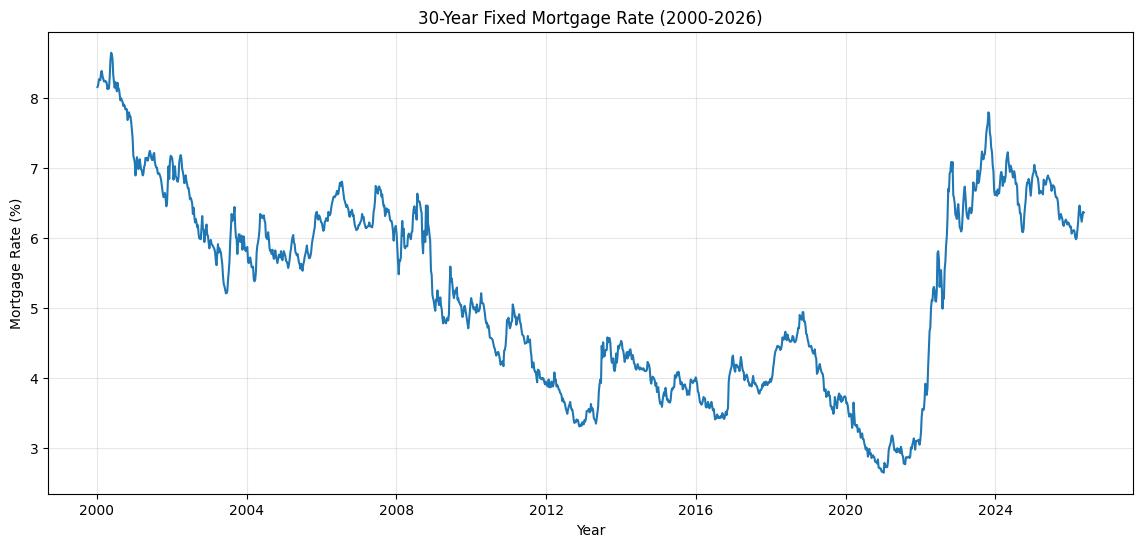

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    mortgage_2000["observation_date"],
    mortgage_2000["MORTGAGE30US"],
    linewidth=1.5
)

plt.title("30-Year Fixed Mortgage Rate (2000-2026)")
plt.xlabel("Year")
plt.ylabel("Mortgage Rate (%)")

plt.grid(alpha=0.3)

plt.show()

* High rates from 2000s gradually declined and dropped during after the 2008 housing crisis.
* Rates rapidly increased from around 2022 and it remains to be seen how the rates will go either rising more or declining for the future.

### HPI Comparison with Mortgage Rates

In [ ]:
#converting weekly mortgage rates into annual averages
mortgage_yearly = (
    df_mortgage
    .set_index("observation_date")
    .resample("YE")["MORTGAGE30US"]
    .mean()
    .reset_index()
)


In [ ]:
mortgage_yearly.head(), mortgage_yearly.shape

(  observation_date  MORTGAGE30US
 0       1971-12-31      7.541750
 1       1972-12-31      7.383269
 2       1973-12-31      8.044808
 3       1974-12-31      9.187115
 4       1975-12-31      9.047115,
 (56, 2))

In [ ]:
#create a year column for Mortgage data
mortgage_yearly['year'] = mortgage_yearly['observation_date'].dt.year

In [ ]:
#create a year column for Collin HPI data
df_collin_hpi['year'] = df_collin_hpi['observation_date'].dt.year

In [ ]:
#merge the two together
collin_mortgage = pd.merge(
    df_collin_hpi,
    mortgage_yearly,
    on="year",
    how="inner"
)

In [ ]:
collin_mortgage.head()

,observation_date_x,ATNHPIUS48085A,year,observation_date_y,MORTGAGE30US
0,1975-01-01,36.17,1975,1975-12-31,9.047115
1,1976-01-01,40.61,1976,1976-12-31,8.865849
2,1977-01-01,43.83,1977,1977-12-31,8.845192
3,1978-01-01,49.36,1978,1978-12-31,9.641731
4,1979-01-01,59.18,1979,1979-12-31,11.203654


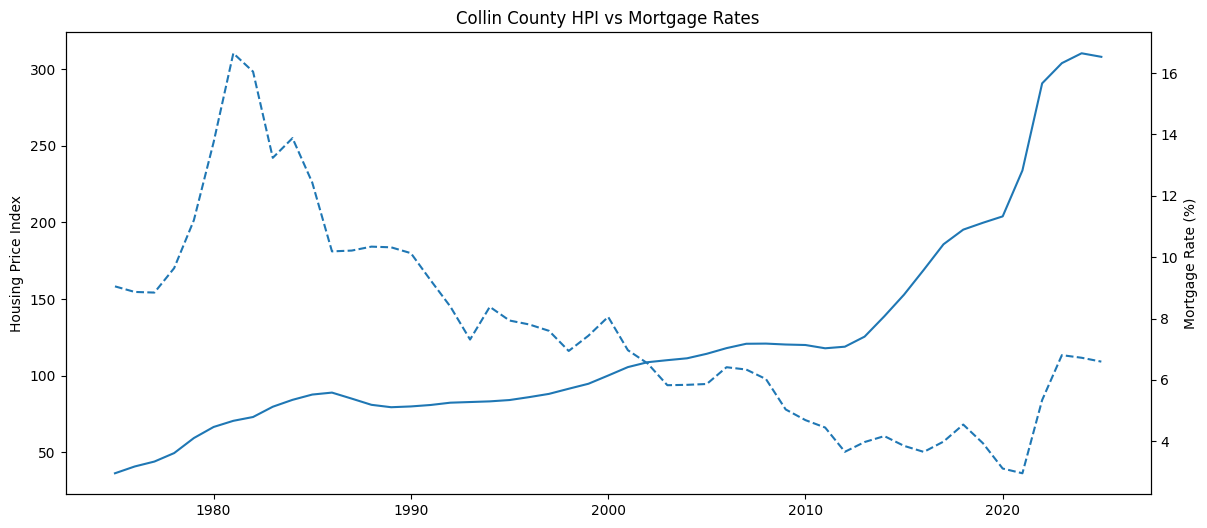

In [ ]:
#create chart
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    collin_mortgage["year"],
    collin_mortgage["ATNHPIUS48085A"],
    label="Collin HPI"
)
ax1.set_ylabel("Housing Price Index")

ax2 = ax1.twinx()

ax2.plot(
    collin_mortgage["year"],
    collin_mortgage["MORTGAGE30US"],
    linestyle="--",
    label="Mortgage Rate"
)
ax2.set_ylabel("Mortgage Rate (%)")

plt.title("Collin County HPI vs Mortgage Rates")

plt.show()

* As the mortgage rates declined over decades, we see a significant increase in HPI.
* After the 2008 housing crisis, mortgage rates continued to decline while the HPI continued to steadily increase.
* After 2022 and forward, mortgage rates rose sharply and HPI still increased. This suggests that housing prices have been slow to adjust to changes in interest rates.

### Multi-County HPI Comparison

In [ ]:
# gathering dataframes
df_collin_hpi = dfs['collin_hpi']
df_dallas_hpi = dfs['dallas_hpi']
df_denton_hpi = dfs['denton_hpi']

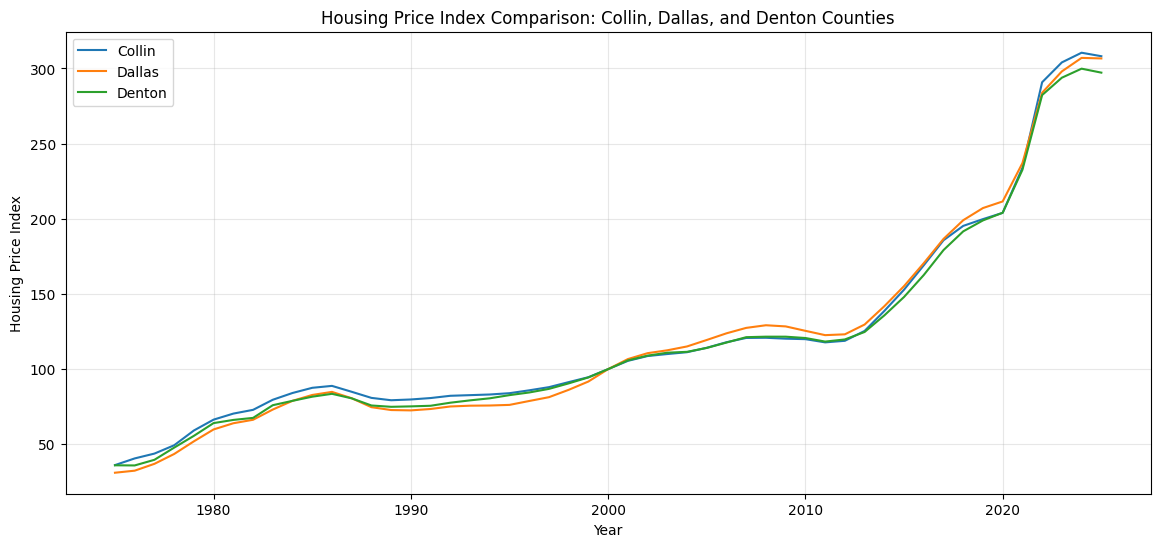

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df_collin_hpi["observation_date"],
    df_collin_hpi["ATNHPIUS48085A"],
    label="Collin"
)

plt.plot(
    df_dallas_hpi["observation_date"],
    df_dallas_hpi["ATNHPIUS48113A"],
    label="Dallas"
)

plt.plot(
    df_denton_hpi["observation_date"],
    df_denton_hpi["ATNHPIUS48121A"],
    label="Denton"
)

plt.title("Housing Price Index Comparison: Collin, Dallas, and Denton Counties")
plt.xlabel("Year")
plt.ylabel("Housing Price Index")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

* Collin County ends up with the highest HPI by 2025 followed by Dallas, and then Denton.
* From 2020, we can see a sharp rise in HPI among all three counties with Collin rising the most and continuing from 2022.
* From 2020, Dallas remains ahead of Denton County although the gap appears smaller than in earlier years.
* In 2008, Dallas remained at a higher HPI than Collin and Denton counties.

In [ ]:
df_dallas_hpi.tail()

,observation_date,ATNHPIUS48113A
46,2021-01-01,237.04
47,2022-01-01,283.86
48,2023-01-01,298.04
49,2024-01-01,307.02
50,2025-01-01,306.66


In [ ]:
df_denton_hpi.tail()

,observation_date,ATNHPIUS48121A
46,2021-01-01,232.58
47,2022-01-01,282.30
48,2023-01-01,293.84
49,2024-01-01,299.85
50,2025-01-01,297.21


#### HPI Rankings

1. Collin County - Highest HPI
2. Dallas County - Second Highest HPI
3. Denton County - Third Highest HPI

All three counties experienced substantial housing price appreciation and Collin Couunty came out on top with the highest HPI by 2025. After 2020, we see rapid appreciation across all three counties with Collin County showing the strongest growth.

### HPI Growth by County

In [ ]:
#calculating Collin Country HPI growth
collin_growth = (
    (df_collin_hpi['ATNHPIUS48085A'].iloc[-1] - df_collin_hpi['ATNHPIUS48085A'].iloc[0]) / df_collin_hpi['ATNHPIUS48085A'].iloc[0]
) * 100

print(f"Collin County HPI Growth: {collin_growth: .2f}%")

Collin County HPI Growth:  751.92%


In [ ]:
#calculate Dallas county growth
dallas_growth = (
    (df_dallas_hpi["ATNHPIUS48113A"].iloc[-1]
     - df_dallas_hpi["ATNHPIUS48113A"].iloc[0])
    / df_dallas_hpi["ATNHPIUS48113A"].iloc[0]
) * 100

print(f"Dallas County HPI Growth: {dallas_growth:.2f}%")

Dallas County HPI Growth: 886.05%


In [ ]:
#calculate Denton county growth
denton_growth = (
    (df_denton_hpi["ATNHPIUS48121A"].iloc[-1]
     - df_denton_hpi["ATNHPIUS48121A"].iloc[0]
) / df_denton_hpi["ATNHPIUS48121A"].iloc[0]
) * 100

print(f"Denton County HPI Growth: {denton_growth:.2f}%")

Denton County HPI Growth: 724.67%


* Dallas county leads Collin with 886.05% overall growth followed by Collin county with 751.95% growth.
* Denton county had the lowest overall growth at 724.67%.

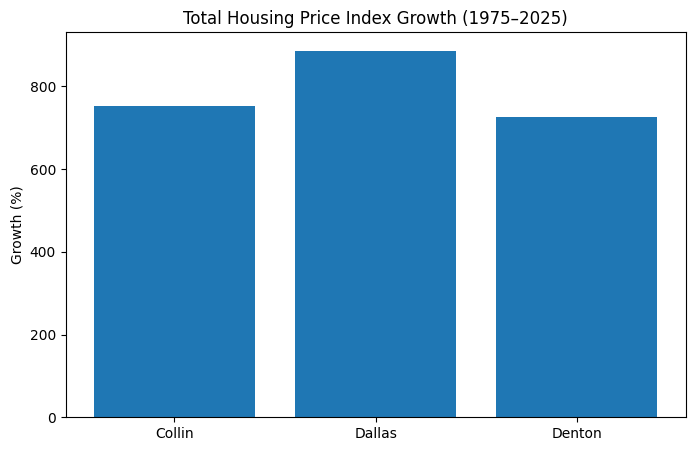

In [ ]:
growth_data = {
    "Collin": collin_growth,
    "Dallas": dallas_growth,
    "Denton": denton_growth
}

plt.figure(figsize=(8,5))
plt.bar(growth_data.keys(), growth_data.values())

plt.title("Total Housing Price Index Growth (1975–2025)")
plt.ylabel("Growth (%)")

plt.show()

Overall, Collin County achieved the highest HPI level by 2025, while Dallas County experienced the greatest percentage growth over the study period.

#### Final Points on HPI Analysis

* All three counties showed substantial long-term housing price appreciation between 1975 and 2025.
* Collin County achieved the highest HPI value by 2025, indicating the strongest housing price level among the three counties.
* Dallas County experienced the greatest overall percentage growth in HPI (886.05%), followed by Collin County (751.95%) and Denton County (724.67%).
* Housing prices accelerated significantly after 2020 across all counties.
* Despite rising mortgage rates beginning in 2022, HPI continued to increase, suggesting that housing demand, population growth, and other market forces may have offset the impact of higher borrowing costs.
* The three counties generally followed similar long-term trends, although leadership shifted over time between Dallas and Collin counties.

### CPI Analysis

In [ ]:
#sanity checks on cpi datasets
df_cpi = dfs['cpi']

In [ ]:
df_cpi.head()

,observation_date,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [ ]:
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  951 non-null    datetime64[ns]
 1   CPIAUCSL          951 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.0 KB


In [ ]:
df_cpi.columns

Index(['observation_date', 'CPIAUCSL'], dtype='object')

In [ ]:
df_cpi.shape

(951, 2)

In [ ]:
print(df_cpi['CPIAUCSL'].describe())

count    951.000000
mean     124.711897
std       90.013374
min       21.480000
25%       32.865000
50%      109.900000
75%      201.550000
max      332.407000
Name: CPIAUCSL, dtype: float64


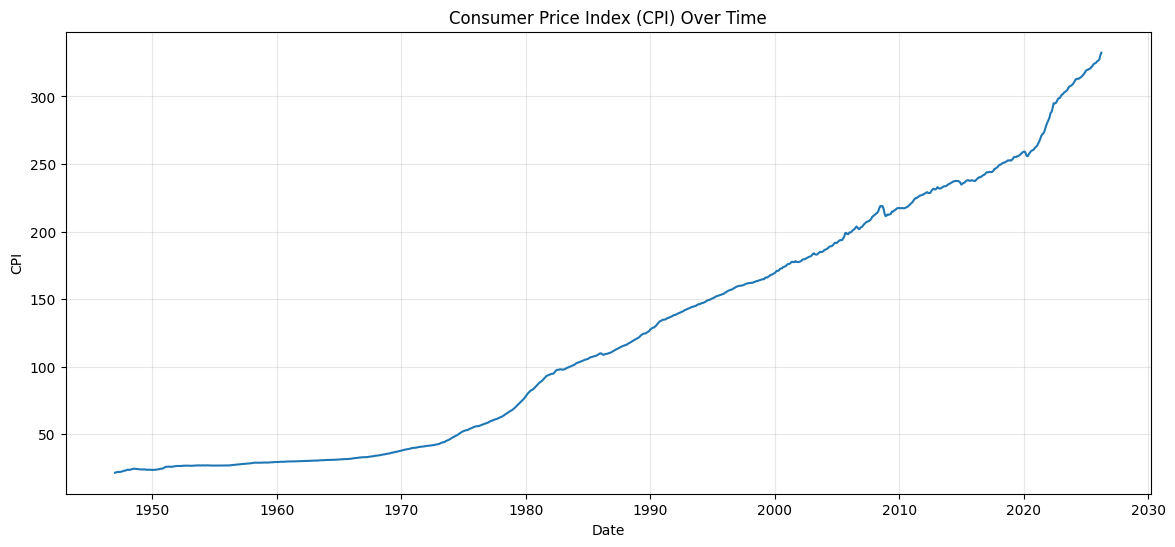

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df_cpi["observation_date"],
    df_cpi["CPIAUCSL"]
)

plt.title("Consumer Price Index (CPI) Over Time")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.grid(alpha=0.3)

plt.show()

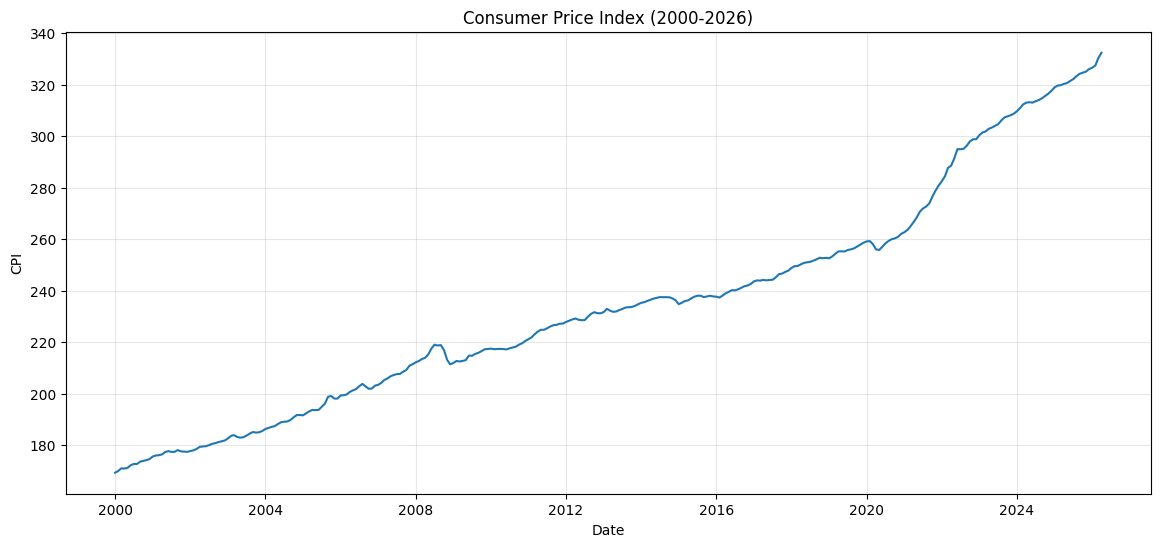

In [ ]:
cpi_recent = df_cpi[
    df_cpi["observation_date"] >= "2000-01-01"
].copy()

plt.figure(figsize=(14,6))

plt.plot(
    cpi_recent["observation_date"],
    cpi_recent["CPIAUCSL"]
)

plt.title("Consumer Price Index (2000-2026)")
plt.xlabel("Date")
plt.ylabel("CPI")

plt.grid(alpha=0.3)

plt.show()

* Post 2000, consumer prices increased much more rapidly between 2020 and 2024 than during most previous four-year periods in the dataset.
* Overall, prices have steadily risen from 2000 up to 2020.
* We see a short slowdown after the 2008 financial crisis.
* However, consumer prices have more sharplly increased from 2021 onward into 2024 and beyond.

In [ ]:
df_cpi[df_cpi["observation_date"].dt.year == 2020]["CPIAUCSL"].head()



,CPIAUCSL
876,259.127
877,259.250
878,258.076
879,256.032
880,255.802


In [ ]:
df_cpi[df_cpi["observation_date"].dt.year == 2024]["CPIAUCSL"].head()

,CPIAUCSL
924,309.698
925,310.967
926,312.345
927,313.023
928,313.175


In [ ]:
cpi_2020 = df_cpi.loc[
    df_cpi["observation_date"].dt.year == 2020,
    "CPIAUCSL"
].mean()

cpi_2024 = df_cpi.loc[
    df_cpi["observation_date"].dt.year == 2024,
    "CPIAUCSL"
].mean()

growth = ((cpi_2024 - cpi_2020) / cpi_2020) * 100

print(growth)

21.18647805454068


### Correlation of CPI, Mortgage Rates, HPI, and Unemployment Data

In [ ]:
#checkin mortgage_yearly dataframe to ensure it still exists for use in this heatmap correlation
mortgage_yearly.head()

,observation_date,MORTGAGE30US,year
0,1971-12-31,7.541750,1971
1,1972-12-31,7.383269,1972
2,1973-12-31,8.044808,1973
3,1974-12-31,9.187115,1974
4,1975-12-31,9.047115,1975


In [ ]:
mortgage_yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  56 non-null     datetime64[ns]
 1   MORTGAGE30US      56 non-null     float64       
 2   year              56 non-null     int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 1.2 KB


##### Modifying CPI dataframe for yearly averages

In [ ]:
#creating CPI yearly df for correlation heatmap
cpi_yearly = (
    df_cpi
    .set_index("observation_date")
    .resample("YE")["CPIAUCSL"]
    .mean()
    .reset_index()
)

In [ ]:
#creating new column for year
cpi_yearly["year"] = cpi_yearly["observation_date"].dt.year

In [ ]:
cpi_yearly.head()

,observation_date,CPIAUCSL,year
0,1947-12-31,22.331667,1947
1,1948-12-31,24.045000,1948
2,1949-12-31,23.809167,1949
3,1950-12-31,24.062500,1950
4,1951-12-31,25.973333,1951


In [ ]:
cpi_yearly.shape

(80, 3)

##### Modifying Collin Unemployment Dataframe for yearly averages

In [ ]:
collin_unemp_yearly = (
    df_collin
    .set_index("observation_date")
    .resample("YE")["TXCOLL5URN"]
    .mean()
    .reset_index()
)

In [ ]:
#add year to collin unemployment
collin_unemp_yearly["year"] = (
    collin_unemp_yearly["observation_date"].dt.year
)

In [ ]:
collin_unemp_yearly.head()

,observation_date,TXCOLL5URN,year
0,1990-12-31,3.833333,1990
1,1991-12-31,4.891667,1991
2,1992-12-31,5.250000,1992
3,1993-12-31,4.225000,1993
4,1994-12-31,3.841667,1994


In [ ]:
collin_unemp_yearly.shape

(37, 3)

In [ ]:
#verifying min and max for collin county unemployment df
collin_unemp_yearly["year"].min(), collin_unemp_yearly["year"].max()

(1990, 2026)

##### Modifying Dallas Unemployment Dataframe for yearly averages


In [ ]:
dallas_unemp_yearly = (
    df_dallas
    .set_index("observation_date")
    .resample("YE")["TXDALL3URN"]
    .mean()
    .reset_index()
)

dallas_unemp_yearly["year"] = (
    dallas_unemp_yearly["observation_date"].dt.year
)

In [ ]:
dallas_unemp_yearly.head(), dallas_unemp_yearly.shape

(  observation_date  TXDALL3URN  year
 0       1990-12-31    5.308333  1990
 1       1991-12-31    6.441667  1991
 2       1992-12-31    7.425000  1992
 3       1993-12-31    6.616667  1993
 4       1994-12-31    5.733333  1994,
 (37, 3))

##### Modifying Denton Unemployment Dataframe for yearly averages

In [ ]:
denton_unemp_yearly = (
    df_denton
    .set_index("observation_date")
    .resample("YE")["TXDENT2URN"]
    .mean()
    .reset_index()
)

denton_unemp_yearly["year"] = (
    denton_unemp_yearly["observation_date"].dt.year
)

In [ ]:
denton_unemp_yearly.head(), denton_unemp_yearly.shape

(  observation_date  TXDENT2URN  year
 0       1990-12-31    4.116667  1990
 1       1991-12-31    4.866667  1991
 2       1992-12-31    5.166667  1992
 3       1993-12-31    4.175000  1993
 4       1994-12-31    4.008333  1994,
 (37, 3))

##### Modifying HPI Dataframe for yearly averages

In [ ]:
df_collin_hpi.head()

,observation_date,ATNHPIUS48085A,year
0,1975-01-01,36.17,1975
1,1976-01-01,40.61,1976
2,1977-01-01,43.83,1977
3,1978-01-01,49.36,1978
4,1979-01-01,59.18,1979


In [ ]:
df_dallas_hpi.head()

,observation_date,ATNHPIUS48113A
0,1975-01-01,31.10
1,1976-01-01,32.46
2,1977-01-01,37.02
3,1978-01-01,43.56
4,1979-01-01,51.98


In [ ]:
#dallas and denont hpi df's need a year column, collin hpi already has one
df_dallas_hpi["year"] = (
    df_dallas_hpi["observation_date"].dt.year
)

df_denton_hpi["year"] = (
    df_denton_hpi["observation_date"].dt.year
)

In [ ]:
#verify columns in each dataset
df_collin_hpi.columns, df_dallas_hpi.columns, df_denton_hpi.columns

(Index(['observation_date', 'ATNHPIUS48085A', 'year'], dtype='object'),
 Index(['observation_date', 'ATNHPIUS48113A', 'year'], dtype='object'),
 Index(['observation_date', 'ATNHPIUS48121A', 'year'], dtype='object'))

##### Renaming Column Names for All Datasets

In [ ]:
cpi_yearly.columns

Index(['observation_date', 'CPIAUCSL', 'year'], dtype='object')

In [ ]:
#renaming CPIAUCSL column name to "cpi"
cpi_yearly = cpi_yearly.rename(
    columns={"CPIAUCSL":"cpi"}
)

In [ ]:
cpi_yearly.columns

Index(['observation_date', 'cpi', 'year'], dtype='object')

In [ ]:
mortgage_yearly.columns

Index(['observation_date', 'MORTGAGE30US', 'year'], dtype='object')

In [ ]:
#renaming mortgage column name
mortgage_yearly = mortgage_yearly.rename(
    columns={"MORTGAGE30US": "mortgage_rate"}
)

In [ ]:
mortgage_yearly.columns

Index(['observation_date', 'mortgage_rate', 'year'], dtype='object')

In [ ]:
collin_unemp_yearly.columns

Index(['observation_date', 'TXCOLL5URN', 'year'], dtype='object')

In [ ]:
collin_unemp_yearly = collin_unemp_yearly.rename(
    columns={"TXCOLL5URN": "collin_unemployment"}
)

In [ ]:
collin_unemp_yearly.columns

Index(['observation_date', 'collin_unemployment', 'year'], dtype='object')

In [ ]:
dallas_unemp_yearly.columns

Index(['observation_date', 'TXDALL3URN', 'year'], dtype='object')

In [ ]:
dallas_unemp_yearly = dallas_unemp_yearly.rename(
    columns={"TXDALL3URN":"dallas_unemployment"}
)

In [ ]:
dallas_unemp_yearly.columns

Index(['observation_date', 'dallas_unemployment', 'year'], dtype='object')

In [ ]:
denton_unemp_yearly.columns

Index(['observation_date', 'TXDENT2URN', 'year'], dtype='object')

In [ ]:
denton_unemp_yearly = denton_unemp_yearly.rename(
    columns={"TXDENT2URN":"denton_unemployment"}
)

In [ ]:
denton_unemp_yearly.columns

Index(['observation_date', 'denton_unemployment', 'year'], dtype='object')

In [ ]:
#renaming HPI columns
df_collin_hpi.columns

Index(['observation_date', 'ATNHPIUS48085A', 'year'], dtype='object')

In [ ]:
#rename
df_collin_hpi = df_collin_hpi.rename(
    columns={"ATNHPIUS48085A":"collin_hpi"}
)

In [ ]:
df_collin_hpi.columns

Index(['observation_date', 'collin_hpi', 'year'], dtype='object')

In [ ]:
#rename dallas hpi
df_dallas_hpi.columns

Index(['observation_date', 'ATNHPIUS48113A', 'year'], dtype='object')

In [ ]:
df_dallas_hpi = df_dallas_hpi.rename(
    columns={"ATNHPIUS48113A":"dallas_hpi"}
)

In [ ]:
df_dallas_hpi.columns

Index(['observation_date', 'dallas_hpi', 'year'], dtype='object')

In [ ]:
df_denton_hpi.columns

Index(['observation_date', 'ATNHPIUS48121A', 'year'], dtype='object')

In [ ]:
df_denton_hpi = df_denton_hpi.rename(
    columns={"ATNHPIUS48121A":"denton_hpi"}
)

In [ ]:
df_denton_hpi.columns

Index(['observation_date', 'denton_hpi', 'year'], dtype='object')

In [ ]:
#confirming new column names, observation date, and year
df_collin_hpi.columns, df_dallas_hpi.columns, df_denton_hpi.columns

(Index(['observation_date', 'collin_hpi', 'year'], dtype='object'),
 Index(['observation_date', 'dallas_hpi', 'year'], dtype='object'),
 Index(['observation_date', 'denton_hpi', 'year'], dtype='object'))

### Building Master Dataset for Correlation

In [ ]:
final_df = cpi_yearly[["year","cpi"]]

In [ ]:
final_df.head()

,year,cpi
0,1947,22.331667
1,1948,24.045000
2,1949,23.809167
3,1950,24.062500
4,1951,25.973333


In [ ]:
final_df.shape

(80, 2)

In [ ]:
# merge mortgage rates
final_df = final_df.merge(
    mortgage_yearly[["year","mortgage_rate"]],
    on="year",
    how="inner"
)

In [ ]:
final_df.head()

,year,cpi,mortgage_rate
0,1971,40.483333,7.541750
1,1972,41.808333,7.383269
2,1973,44.425000,8.044808
3,1974,49.316667,9.187115
4,1975,53.825000,9.047115


In [ ]:
final_df.shape

(56, 3)

In [ ]:
final_df.columns

Index(['year', 'cpi', 'mortgage_rate'], dtype='object')

In [ ]:
#merge collin_yearly to final df
final_df = final_df.merge(
    collin_unemp_yearly[["year","collin_unemployment"]],
    on="year",
    how="inner"
)

In [ ]:
final_df.head(), final_df.shape

(   year         cpi  mortgage_rate  collin_unemployment
 0  1990  130.658333      10.129423             3.833333
 1  1991  136.166667       9.246538             4.891667
 2  1992  140.308333       8.390189             5.250000
 3  1993  144.475000       7.314615             4.225000
 4  1994  148.225000       8.380769             3.841667,
 (37, 4))

In [ ]:
#merge dallas yearly to final df
final_df = final_df.merge(
    dallas_unemp_yearly[["year","dallas_unemployment"]],
    on="year",
    how="inner"
)

In [ ]:
final_df.head(), final_df.shape

(   year         cpi  mortgage_rate  collin_unemployment  dallas_unemployment
 0  1990  130.658333      10.129423             3.833333             5.308333
 1  1991  136.166667       9.246538             4.891667             6.441667
 2  1992  140.308333       8.390189             5.250000             7.425000
 3  1993  144.475000       7.314615             4.225000             6.616667
 4  1994  148.225000       8.380769             3.841667             5.733333,
 (37, 5))

In [ ]:
#merge Denton unemployment data onto final df
final_df = final_df.merge(
    denton_unemp_yearly[["year","denton_unemployment"]],
    on="year",
    how="inner"
)

In [ ]:
final_df.head(), final_df.shape

(   year         cpi  mortgage_rate  collin_unemployment  dallas_unemployment  \
 0  1990  130.658333      10.129423             3.833333             5.308333   
 1  1991  136.166667       9.246538             4.891667             6.441667   
 2  1992  140.308333       8.390189             5.250000             7.425000   
 3  1993  144.475000       7.314615             4.225000             6.616667   
 4  1994  148.225000       8.380769             3.841667             5.733333   
 
    denton_unemployment  
 0             4.116667  
 1             4.866667  
 2             5.166667  
 3             4.175000  
 4             4.008333  ,
 (37, 6))

In [ ]:
#adding HPI data from each county using for loop
#creating dictionary of dfs first
hpi_dfs = {
    "collin_hpi": df_collin_hpi,
    "dallas_hpi": df_dallas_hpi,
    "denton_hpi": df_denton_hpi
}


In [ ]:
#creating looop for merging hpi county datasets
for name, df in hpi_dfs.items():
  final_df = final_df.merge(
      df[["year",name]],
      on="year",
      how="inner"
  )

In [ ]:
final_df.shape

(36, 9)

In [ ]:
final_df.columns

Index(['year', 'cpi', 'mortgage_rate', 'collin_unemployment',
       'dallas_unemployment', 'denton_unemployment', 'collin_hpi',
       'dallas_hpi', 'denton_hpi'],
      dtype='object')

In [ ]:
final_df.head()

,year,cpi,mortgage_rate,collin_unemployment,dallas_unemployment,denton_unemployment,collin_hpi,dallas_hpi,denton_hpi
0,1990,130.658333,10.129423,3.833333,5.308333,4.116667,79.82,72.56,75.23
1,1991,136.166667,9.246538,4.891667,6.441667,4.866667,80.77,73.49,75.64
2,1992,140.308333,8.390189,5.250000,7.425000,5.166667,82.27,75.16,77.67
3,1993,144.475000,7.314615,4.225000,6.616667,4.175000,82.70,75.69,79.23
4,1994,148.225000,8.380769,3.841667,5.733333,4.008333,83.13,75.81,80.60


### Correlation Matrix Analysis

In [ ]:
corr_matrix = final_df.corr(numeric_only=True)
corr_matrix

,year,cpi,mortgage_rate,collin_unemployment,dallas_unemployment,denton_unemployment,collin_hpi,dallas_hpi,denton_hpi
year,1.000000,0.985296,-0.756915,0.125005,-0.206242,0.117473,0.879746,0.908937,0.890378
cpi,0.985296,1.000000,-0.648978,0.088742,-0.235590,0.085432,0.932037,0.952551,0.939325
mortgage_rate,-0.756915,-0.648978,1.000000,-0.366660,-0.138796,-0.350636,-0.398459,-0.451407,-0.419395
collin_unemployment,0.125005,0.088742,-0.366660,1.000000,0.924735,0.982046,-0.090448,-0.048275,-0.075620
dallas_unemployment,-0.206242,-0.235590,-0.138796,0.924735,1.000000,0.919426,-0.368517,-0.341349,-0.356491
denton_unemployment,0.117473,0.085432,-0.350636,0.982046,0.919426,1.000000,-0.090153,-0.050611,-0.076481
collin_hpi,0.879746,0.932037,-0.398459,-0.090448,-0.368517,-0.090153,1.000000,0.996926,0.999291
dallas_hpi,0.908937,0.952551,-0.451407,-0.048275,-0.341349,-0.050611,0.996926,1.000000,0.998507
denton_hpi,0.890378,0.939325,-0.419395,-0.075620,-0.356491,-0.076481,0.999291,0.998507,1.000000


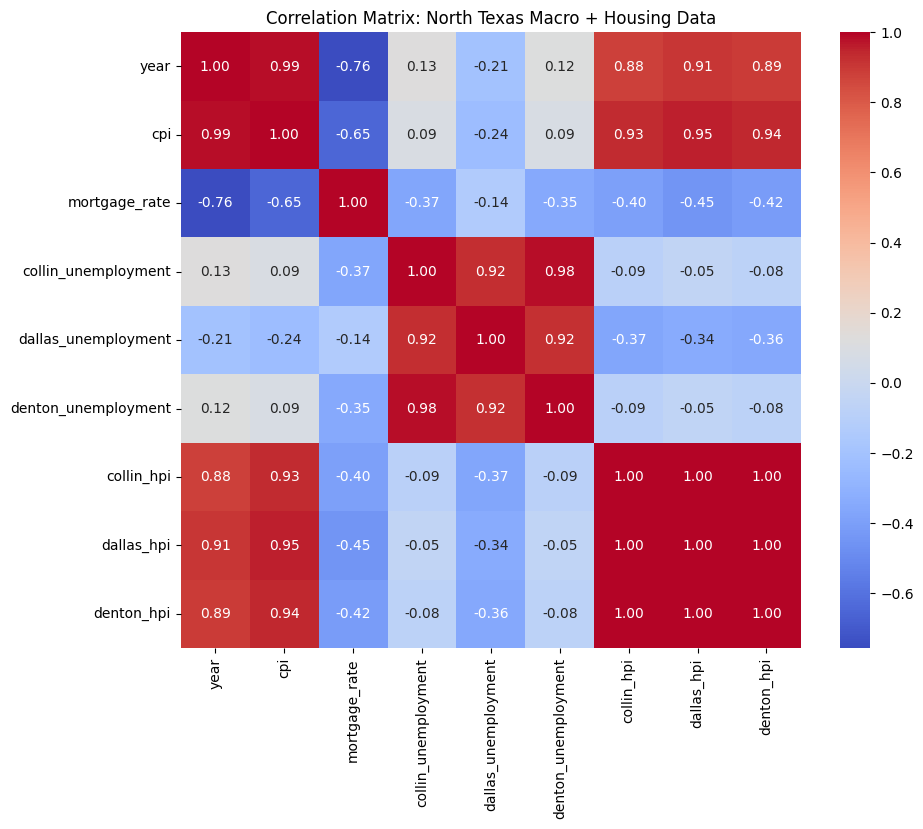

In [ ]:
#heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix: North Texas Macro + Housing Data")
plt.show()

* Housing Prices (HPI) appear to move strongly with inflation numbers (CPI).
* As CPI rises, housing prices across all three counties rise significantly.
* See correlations between CPI and HPI of Collin (0.93), Dallas (0.95), and Denton (0.94).

* Mortgage rates appear to move in a moderate negative correlation.
* Higher mortgage rates are associated with lower housing price growth, but not necessarily the dominant issue.
* Mortgage rates alone do not explain the housing price movement in North Texas. Instead, they act more as a dampening factor on housing prices, but they do not override the broader macro trends of inflation and population growth.

* The Unemployment vs HPI shows a very weak correlation.
* Unemployment is not a strong driver of housing prices in this dataset.


### Conclusion

1. CPI shows the strongest positive correlation with HPI.

2. Mortgage rates are a moderate force and have a negative relationship with HPI, but not strong enough to be a dominating factor.

3. Unemployment is a weak factor and suggests that housing is not highly sensitive to fluctuations in labor at the county level.

### Exporting File to Power BI

In [ ]:
final_df.to_csv(
    "north_texas_macro_dataset.csv",
    index=False
)

In [ ]:
final_df.head()

,year,cpi,mortgage_rate,collin_unemployment,dallas_unemployment,denton_unemployment,collin_hpi,dallas_hpi,denton_hpi
0,1990,130.658333,10.129423,3.833333,5.308333,4.116667,79.82,72.56,75.23
1,1991,136.166667,9.246538,4.891667,6.441667,4.866667,80.77,73.49,75.64
2,1992,140.308333,8.390189,5.250000,7.425000,5.166667,82.27,75.16,77.67
3,1993,144.475000,7.314615,4.225000,6.616667,4.175000,82.70,75.69,79.23
4,1994,148.225000,8.380769,3.841667,5.733333,4.008333,83.13,75.81,80.60
